In [1]:
import numpy as np 
import h5py as h5 
import matplotlib.pyplot as plt

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

from scipy.interpolate import UnivariateSpline
from scipy.optimize import minimize

from compact.lpt import *
from compact.streaming import *
from compact.model import *
from compact.plot import *

from bin_utils import *

from halotools.mock_observables import tpcf_multipole


from tqdm import tqdm
import emcee

from scipy.interpolate import UnivariateSpline

import warnings
warnings.filterwarnings('ignore')

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20


import colossus
import pandas as pd

# reload project when changes are made
%load_ext autoreload
%autoreload 2 

In [2]:
dex_width = 0.1  # bin width in log10(mass); narrower = 0.1, wider = 0.3
log_edges = np.arange(np.log10(1e13), np.log10(1e15) + dex_width, dex_width)
massbins = np.column_stack([10**log_edges[:-1], 10**log_edges[1:]])[::6] # select 4 bins from the full set of mass bins
print(np.log10(massbins))

[[13.  13.1]
 [13.6 13.7]
 [14.2 14.3]
 [14.8 14.9]]


In [7]:
cosmo_nums = np.array([1992, 1994, 1927, 1986, 1852])

available_sim_nums = np.array([                                                    # only this subset of the 2000 sims are available on spiffball
    1402, 1655, 1740, 1791, 1807, 1820, 1839, 1861, 1889, 1902, 1911, 1915, 1923,
    1930, 1936, 1945, 1952, 1962, 1966, 1974, 1979, 1984, 1988, 1992, 1996,
    1625, 1656, 1757, 1793, 1810, 1824, 1852, 1871, 1894, 1906, 1912, 1916, 1927,
    1933, 1937, 1948, 1955, 1963, 1967, 1975, 1980, 1985, 1989, 1993, 1997,
    1630, 1659, 1764, 1795, 1818, 1826, 1857, 1877, 1897, 1907, 1913, 1919, 1928,
    1934, 1943, 1949, 1956, 1964, 1970, 1976, 1982, 1986, 1990, 1994, 1998,
    1640, 1704, 1769, 1797, 1819, 1835, 1859, 1887, 1898, 1909, 1914, 1921, 1929,
    1935, 1944, 1950, 1960, 1965, 1972, 1977, 1983, 1987, 1991, 1995, 590,
])

sim_nums = [i for i in range(2_000)] # all cosmologies

q_cosmos = np.zeros((len(sim_nums), 5))

for num in sim_nums:
    dat_path = f'/spiffball/edgarmsc/simulations/Quijote/Snapshots/latin_hypercube_HR_cosmo/Cosmo_params_{num}.dat'

    df = pd.read_csv(dat_path, sep=r'\s+', header=None, names=['Om', 'Ob', 'h', 'ns', 's8'])

    q_cosmos[num] = df.values[0]

LH_cosmos = q_cosmos[cosmo_nums]

LH_cosmos

array([[0.1499 , 0.03475, 0.8141 , 1.1023 , 0.6011 ],
       [0.2927 , 0.04833, 0.5623 , 0.8073 , 0.8415 ],
       [0.1881 , 0.06873, 0.6485 , 1.0081 , 0.6871 ],
       [0.4977 , 0.05655, 0.6983 , 1.1879 , 0.8765 ],
       [0.3775 , 0.03797, 0.8971 , 0.8891 , 0.9479 ]])

In [11]:
test_path = '/spiffball/edgarmsc/simulations/Quijote/Halos/Rockstar/latin_hypercube_HR/1889/hlist_4.hdf5'

with h5.File(test_path, 'r') as hdf:
    print(hdf.keys())
    print(len(hdf['X'][()]))

<KeysViewHDF5 ['A[x]', 'A[x](500c)', 'A[y]', 'A[y](500c)', 'A[z]', 'A[z](500c)', 'DescID', 'Halfmass_Radius', 'ID', 'JX', 'JY', 'JZ', 'M200b', 'M200c', 'M2500c', 'M500c', 'M_pe_Behroozi', 'M_pe_Diemer', 'Mvir', 'Mvir_all', 'Np', 'PID', 'Rs', 'Rvir', 'Spin', 'T\\|U|', 'VX', 'VY', 'VZ', 'Vmax', 'Voff', 'Vrms', 'X', 'Xoff', 'Y', 'Z', 'b_to_a', 'b_to_a(500c)', 'c_to_a', 'c_to_a(500c)', 'rs_klypin', 'spin_bullock']>
924941


In [10]:
# generate halo sub boxes 
halo_path = test_path #'/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'

sim_num = 1889

hsb_path = f'/spiffball/cosweeney/simulations/Quijote/halos/{sim_num}/SBp/'

vel_path = f'/spiffball/cosweeney/simulations/Quijote/halos/{sim_num}/data/pairwise_velocity_selections/halo_halo_pairs_no_vlos_cut_1e13_mass_cut_SB250.hdf5'

box_length = 1000 #Mpc/h, MDPL2 box side length

with h5.File(halo_path, 'r') as hcat:
    hm_cut = hcat['Mvir'][()] >= 1e13

    hpos = np.array([
        hcat['X'][()][hm_cut],
        hcat['Y'][()][hm_cut], 
        hcat['Z'][()][hm_cut],
    ]).T 

    hvel = np.array([
        hcat['VX'][()][hm_cut],
        hcat['VY'][()][hm_cut], 
        hcat['VZ'][()][hm_cut],
    ]).T

    hid = hcat['ID'][()][hm_cut]
    upid = hcat['PID'][()][hm_cut]

    generate_sub_box_ids(hpos%box_length, box_length, box_length / 4, hid.shape[0] // 1000, hsb_path, name='halo')

    split_simulation_into_sub_boxes(
        positions=hpos%box_length, 
        velocities=hvel, 
        ids=hid, 
        upids=upid,
        boxsize=box_length, 
        subsize=box_length / 4,
        chunksize=hid.shape[0] // 1000, 
        dtypes=[hpos[0].dtype, hvel[0].dtype], 
        path=hsb_path, 
        name='halo'
    )



Chunk:   0%|                                                               | 0/1000 [00:00<?, ?it/s]

	● Elapsed time: 0:00:00.100636 generate_sub_box_ids


Chunk:   0%|                                                               | 0/1000 [00:00<?, ?it/s]

	● Elapsed time: 0:00:03.943992 split_simulation_into_sub_boxes


In [30]:
# check cosmo

test_dat = f'/spiffball/edgarmsc/simulations/Quijote/Snapshots/latin_hypercube_HR_cosmo/Cosmo_params_{sim_num}.dat'

df = pd.read_csv(test_dat, sep=r'\s+', header=None, names=['Om', 'Ob', 'h', 'ns', 's8'])

print(df.head())

params = {'flat': True, 'H0': 100 * df['h'][0], 'Om0': df['Om'][0], 'Ob0': df['Ob'][0], 'sigma8': df['s8'][0], 'ns': df['ns'][0]}

cosmo = cosmology.setCosmology('myCosmo', params)

       Om       Ob       h      ns      s8
0  0.3345  0.03171  0.7971  1.0785  0.6753


In [41]:
df.values

array([[0.3345 , 0.03171, 0.7971 , 1.0785 , 0.6753 ]])

In [59]:
np.diff(np.log10(massbins))

array([[0.30103   ],
       [0.07918125],
       [0.09691001]])

In [60]:
np.log10(1e13)

np.float64(13.0)

In [35]:
halo_path = test_path #'/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'
sim_num = 1889

hsb_path = f'/spiffball/cosweeney/simulations/Quijote/halos/{sim_num}/SBp/'

vel_path = f'/spiffball/cosweeney/simulations/Quijote/halos/{sim_num}/data/pairwise_velocity_selections/halo_halo_pairs_no_vlos_cut_1e13_mass_cut_SB250.hdf5'

box_length = 1000 #Mpc/h, MDPL2 box side length

massbins = np.array([[1e13, 2e13], [5e13, 6e13], [8e13, 1e14]])

with h5.File(halo_path, 'r') as hcat:    
    
    for k in range(len(massbins)):
        mcut = (hcat['Mvir'][()] >= massbins[k][0]) & (hcat['Mvir'][()] <= massbins[k][1]) # h^-1 M_sun

        hid = hcat['ID'][()][mcut]

        rel_r, rel_R, rel_rlos, vpeclos, vphyslos, rel_vr, rel_vt, hupid, hsbid = select_halos_around_haloes_parallel( len(hid), 140, box_length, box_length / 4, halo_path, hsb_path, mass_mask=mcut, H=cosmo.Hz(0), h=cosmo.h, n_jobs=84)  

        with h5.File(vel_path, 'w') as hdf:
            hdf.create_dataset(name=f'r/{k}', data=rel_r, dtype=np.float64) 
            hdf.create_dataset(name=f'R/{k}', data=rel_R, dtype=np.float64) 
            hdf.create_dataset(name=f'rlos/{k}', data=rel_rlos, dtype=np.float64) 
            hdf.create_dataset(name=f'vpeclos/{k}', data=vpeclos, dtype=np.float64) 
            hdf.create_dataset(name=f'vphyslos/{k}', data=vphyslos, dtype=np.float64) 
            hdf.create_dataset(name=f'vr/{k}', data=rel_vr, dtype=np.float64)
            hdf.create_dataset(name=f'vt/{k}', data=rel_vt, dtype=np.float64) 
            hdf.create_dataset(name=f'hupid/{k}', data=hupid, dtype=np.float64)
            hdf.create_dataset(name=f'hsbid/{k}', data=hsbid, dtype=np.float64)

Processing sub-box:   0%|                                                    | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

/home/cosweeney/code/compact_streaming/nb/bin_utils.py:321: RuntimeWarning: invalid value encountered in divide
  vr = np.sum(pos * vel, axis=1) / r3d
/home/cosweeney/code/compact_streaming/nb/bin_utils.py:321: RuntimeWarning: invalid value encountered in divide
  vr = np.sum(pos * vel, axis=1) / r3d
/home/cosweeney/code/compact_streaming/nb/bin_utils.py:321: RuntimeWarning: invalid value encountered in divide
  vr = np.sum(pos * vel, axis=1) / r3d
/home/cosweeney/code/compact_streaming/nb/bin_utils.py:321: RuntimeWarning: invalid value encountered in divide
  vr = np.sum(pos * vel, axis=1) / r3d
/home/cosweeney/code/compact_streaming/nb/bin_utils.py:321: RuntimeWarning: invalid value encountered in divide
  vr = np.sum(pos * vel, axis=1) / r3d
/home/cosweeney/code/compact_streaming/nb/bin_utils.py:321: RuntimeWarning: invalid value encountered in divide
  vr = np.sum(pos * vel, axis=1) / r3d
/home/cosweeney/code/compact_streaming/nb/bin_utils.py:321: RuntimeWarning: invalid value enco

	● Elapsed time: 0:10:11.452086 select_halos_around_haloes_parallel


FileNotFoundError: [Errno 2] Unable to synchronously create file (unable to open file: name = '/spiffball/cosweeney/simulations/Quijote/halos/1889/data/pairwise_velocity_selections/halo_halo_pairs_no_vlos_cut_1e13_mass_cut_SB250.hdf5', errno = 2, error message = 'No such file or directory', flags = 13, o_flags = 242)

In [93]:
#massbins = np.array([[1e13, 2e13], [5e13, 6e13], [3e14, 1e15]])
sim_num = 1992

cosmo_nums = np.array([1992, 1994, 1927, 1986, 1852])

for sim_num in cosmo_nums:

    halo_path_test = f'/spiffball/edgarmsc/simulations/Quijote/Halos/Rockstar/latin_hypercube_HR/{sim_num}/hlist_4.hdf5'

    dex_width = 0.1  # bin width in log10(mass); narrower = 0.1, wider = 0.3
    log_edges = np.arange(np.log10(1e13), np.log10(1e15) + dex_width, dex_width)
    massbins = np.column_stack([10**log_edges[:-1], 10**log_edges[1:]])[::6] # select 4 bins from the full set of mass bins

    # print(massbins)

    with h5.File(halo_path_test, 'r') as hcat:    
        
        for k in range(len(massbins)):
            mcut = (hcat['Mvir'][()] >= massbins[k][0]) & (hcat['Mvir'][()] <= massbins[k][1]) # h^-1 M_sun
            print(np.sum(mcut))

26892
3621
216
0
71714
18159
3582
351
36117
6598
757
34
164538
63873
14044
1200
134521
40009
8976
998


In [79]:
#4/64 [03:41<54:11, 54.19s/it]
#64/64 [08:58<00:00,  7.01s/it]
# For 5 cosmologies and 3 mass bins, implies around 15 hrs (or ~ 2.5 hours with parallelization) to compute all the pairwise velocity selections for the Quijote simulations.
# let's select the cosmologies we'll use. 

available_sim_nums = np.array([                                                    # only this subset of the 2000 sims are available on spiffball
    1402, 1655, 1740, 1791, 1807, 1820, 1839, 1861, 1889, 1902, 1911, 1915, 1923,
    1930, 1936, 1945, 1952, 1962, 1966, 1974, 1979, 1984, 1988, 1992, 1996,
    1625, 1656, 1757, 1793, 1810, 1824, 1852, 1871, 1894, 1906, 1912, 1916, 1927,
    1933, 1937, 1948, 1955, 1963, 1967, 1975, 1980, 1985, 1989, 1993, 1997,
    1630, 1659, 1764, 1795, 1818, 1826, 1857, 1877, 1897, 1907, 1913, 1919, 1928,
    1934, 1943, 1949, 1956, 1964, 1970, 1976, 1982, 1986, 1990, 1994, 1998,
    1640, 1704, 1769, 1797, 1819, 1835, 1859, 1887, 1898, 1909, 1914, 1921, 1929,
    1935, 1944, 1950, 1960, 1965, 1972, 1977, 1983, 1987, 1991, 1995, 590,
])

sim_nums = [i for i in range(2_000)]

q_cosmos = np.zeros((len(sim_nums), 5))

for num in sim_nums:
    dat_path = f'/spiffball/edgarmsc/simulations/Quijote/Snapshots/latin_hypercube_HR_cosmo/Cosmo_params_{num}.dat'

    df = pd.read_csv(dat_path, sep=r'\s+', header=None, names=['Om', 'Ob', 'h', 'ns', 's8'])

    q_cosmos[num] = df.values[0]

q_cosmos_available = q_cosmos[available_sim_nums]


def select_lh_subset(params, k=5, rng=None, max_attempts=1000):
    """
    params : (N, d) array of cosmological parameters (e.g. Om, Ob, h, ns, s8)
    k      : number of sims to select == number of quantile bins per parameter
    Returns indices of k rows such that, for every parameter column, the k
    selected rows occupy k distinct quantile bins (a Latin-hypercube-like subset).
    """
    if rng is None:
        rng = np.random.default_rng()

    N, d = params.shape

    # assign each sim a quantile bin (0..k-1) per parameter
    bins = np.zeros((N, d), dtype=int)
    for j in range(d):
        edges = np.quantile(params[:, j], np.linspace(0, 1, k + 1))
        bins[:, j] = np.clip(np.searchsorted(edges, params[:, j], side='right') - 1, 0, k - 1)

    for _ in range(max_attempts):
        order = rng.permutation(N)
        used_bins = [set() for _ in range(d)]
        chosen = []

        for idx in order:
            row_bins = bins[idx]
            if all(row_bins[j] not in used_bins[j] for j in range(d)):
                chosen.append(idx)
                for j in range(d):
                    used_bins[j].add(row_bins[j])
                if len(chosen) == k:
                    return np.array(chosen), bins[chosen]

    raise RuntimeError(f"Couldn't find a valid Latin-hypercube-like subset in {max_attempts} attempts")

# params = np.loadtxt('latin_hypercube_params.txt')  # columns: Om, Ob, h, ns, s8
# selected_idx, selected_bins = select_lh_subset(params, k=5)
# print(selected_bins)  # each column should be a permutation of 0..4

selected_idx, selected_bins = select_lh_subset(q_cosmos_available, k=5)

In [82]:
available_sim_nums[selected_idx]

array([1992, 1994, 1927, 1986, 1852])

In [83]:
q_cosmos[selected_idx, xi]

array([0.9331, 0.8335, 1.1437, 1.0521, 1.1835])

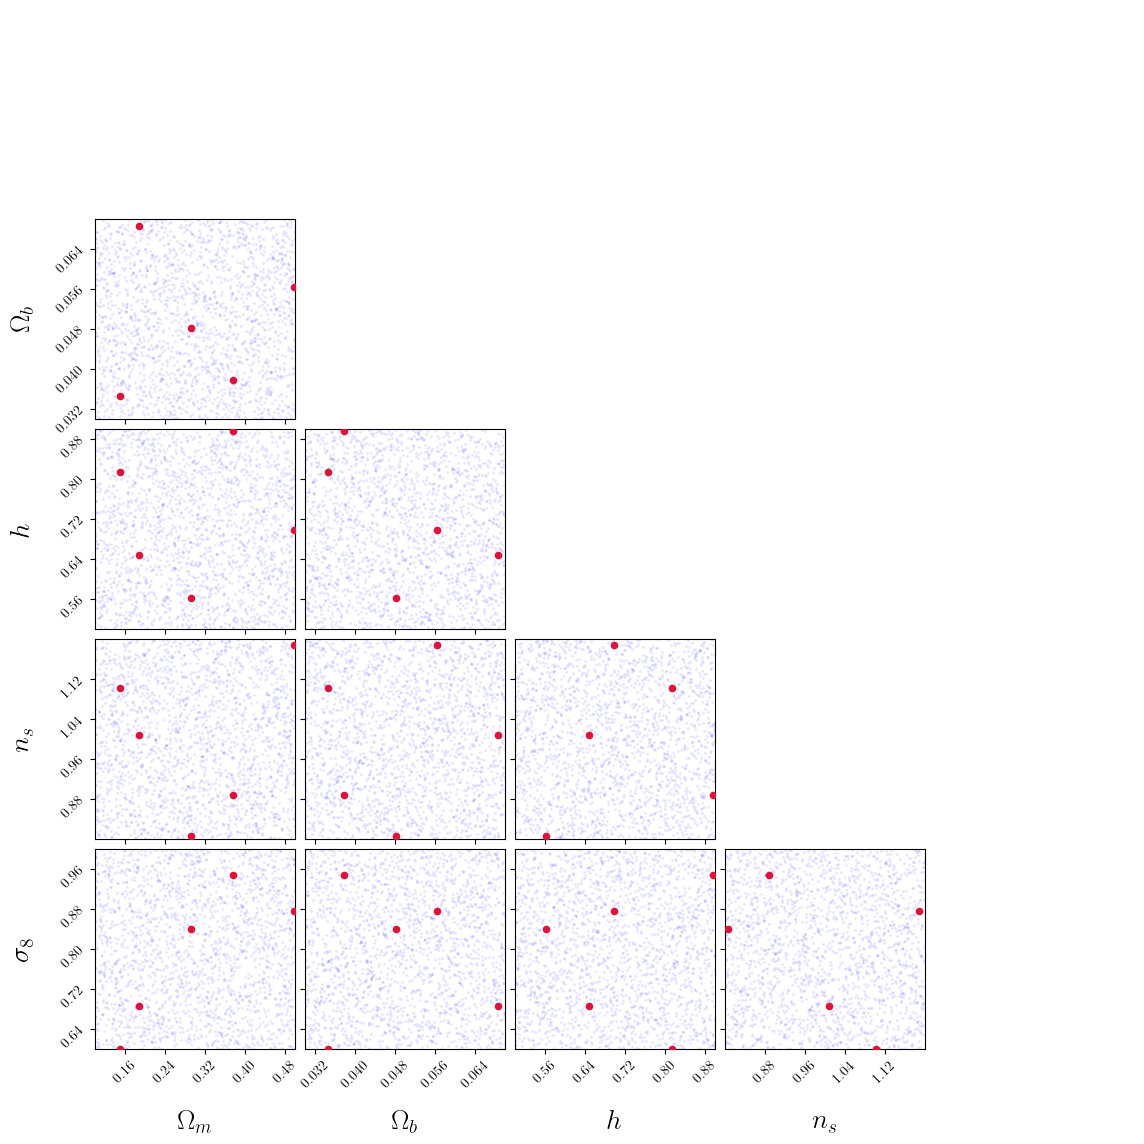

In [84]:
import corner

labels = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$']

fig = corner.corner(
    q_cosmos,
    labels=labels,
    color='blue',
    plot_datapoints=True,
    plot_density=False,
    plot_contours=False,
)

d = q_cosmos.shape[1]
axes = np.array(fig.axes).reshape((d, d))

for i in range(d):
    axes[i, i].set_visible(False)

# overlay selected cosmologies on the lower-triangle scatter panels
for yi in range(d):
    for xi in range(yi):
        axes[yi, xi].scatter(
            q_cosmos_available[selected_idx, xi], q_cosmos_available[selected_idx, yi],
            color='crimson', s=20, zorder=5,
        )

# # mark each selected sim's value on the diagonal (marginal) panels
# for i in range(d):
#     for idx in selected_idx:
#         axes[i, i].axvline(q_cosmos[idx, i], color='crimson', lw=1)

plt.show()